In [1]:
import numpy as np # numpy package
import pandas as pd # pandas pd

### Part 1: Complete the manual PCA calculations with Python as we demonstrated in class. (30 points)

In [5]:
df = pd.DataFrame( # manual dataframe
    {
        "x1":[2.5,0.5,2.2,1.9,3.1,2.3,2.0,1.0,1.5,1.1], # Kai's x1 values
        "x2":[2.4,0.7,2.9,2.2,3.0,2.7,1.6,1.1,1.6,0.9] # Kai's x2 values
    }
)

X = df.values # variable of all dataframe's values
print(X) # print X

[[2.5 2.4]
 [0.5 0.7]
 [2.2 2.9]
 [1.9 2.2]
 [3.1 3. ]
 [2.3 2.7]
 [2.  1.6]
 [1.  1.1]
 [1.5 1.6]
 [1.1 0.9]]


In [9]:
# standardize data
# step 1
X_mean = X.mean(axis=0) # average 
X_std = X.std(axis=0,ddof=1) # ddof=1: sample std
X_scaled = (X-X_mean)/X_std # standardization

print("Mean: ",X_mean) # print mean 
print("Standard deviation: ",X_std) # print standard deviation
print("Standardization: ",X_scaled) # print standardization

Mean:  [1.81 1.91]
Standard deviation:  [0.78521052 0.84649605]
Standardization:  [[ 0.87874523  0.57885681]
 [-1.6683424  -1.42942192]
 [ 0.49668209  1.16952702]
 [ 0.11461894  0.34258872]
 [ 1.64287153  1.28766107]
 [ 0.62403647  0.93325894]
 [ 0.24197333 -0.36621553]
 [-1.03157049 -0.95688575]
 [-0.39479858 -0.36621553]
 [-0.90421611 -1.19315383]]


In [10]:
# Step 2: Compute the Covariance Matrix

cov_matrix = np.cov(X_scaled.T) # create covariance (cov) matrix
print(cov_matrix) # print cov matrix

[[1.         0.92592927]
 [0.92592927 1.        ]]


In [17]:
# Step 3: Eigenvalues and Eigenvectors of the Covariance Matrix
eigvals,eigvecs = np.linalg.eig(cov_matrix) # setting eigvals and eigvec values
print("\nEigenvalues: ",eigvals) # print eigvals
print("\nEigenvectors: ",eigvecs) # print eigvecs


Eigenvalues:  [1.92592927 0.07407073]

Eigenvectors:  [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [26]:
# Step 4: Form the Projection Matrix
W = eigvecs # setting variable to eigvecs
Z = X_scaled @ W # didn't clarify what this meant
print(Z) # print Z

[[ 1.03068029 -0.21205314]
 [-2.19045016  0.1689423 ]
 [ 1.17818776  0.47577321]
 [ 0.32329464  0.16119898]
 [ 2.07219947 -0.25117173]
 [ 1.10117414  0.2186533 ]
 [-0.08785251 -0.43005447]
 [-1.40605089  0.05281009]
 [-0.53811824  0.02021127]
 [-1.48306451 -0.20430982]]


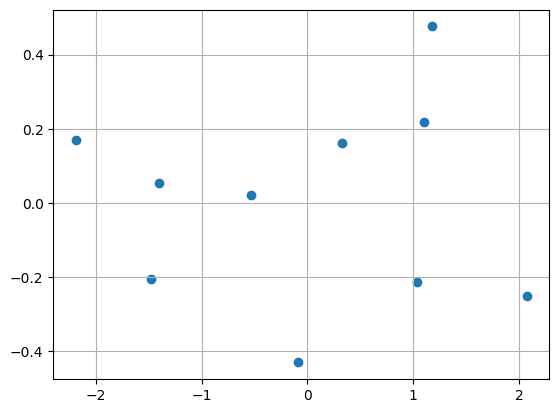

In [38]:
import matplotlib.pyplot as plt
plt.figure() # opening to creating plot
plt.scatter(Z[:,0],Z[:,1])
plt.grid(True)
plt.show() # show final plot

### Part 2: Complete the PCA calculations using sk-learn in Python as we demonstrated in class. (30 points)

In [39]:
from sklearn.preprocessing import StandardScaler #StandardScaler
from sklearn.decomposition import PCA #PCA

In [40]:
scaler = StandardScaler() # standardization
X_scaled_sk = scaler.fit_transform(X) # fit X variable into standardscaler

In [41]:
pca = PCA(n_components=2) #PCA
X_pca = pca.fit_transform(X_scaled_sk) # fit X variable into PCA

In [42]:
print(pca.explained_variance_ratio_) # pca explained variance ratio

[0.96296464 0.03703536]


In [43]:
print(pca.components_) # print pca components

[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]


In [44]:
print(X_pca) # print pca X

[[ 1.08643242 -0.22352364]
 [-2.3089372   0.17808082]
 [ 1.24191895  0.501509  ]
 [ 0.34078247  0.16991864]
 [ 2.18429003 -0.26475825]
 [ 1.16073946  0.23048082]
 [-0.09260467 -0.45331721]
 [-1.48210777  0.05566672]
 [-0.56722643  0.02130455]
 [-1.56328726 -0.21536146]]


### Part 3: Compare the results of the manual calculations and the sk-learn outputs. (10 points)

In [55]:
from sklearn.datasets import load_wine # wine dataset
from sklearn.model_selection import train_test_split

X,y = load_wine(return_X_y=True) # setting X and y values
sc = StandardScaler() # standard scaler
X_scaled_2 = sc.fit_transform(X) # fitting information 

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=11162025) # initialize t_t_s

In [56]:
# Model without PCA
from sklearn.neighbors import KNeighborsClassifier # KNNClassifier package

knn = KNeighborsClassifier(n_neighbors=5) # initialization
knn.fit(X_train,y_train) # fitting X and y values to KNN model
pred = knn.predict(X_test) # prediction
knn # print

KNeighborsClassifier()

In [71]:
# Model with PCA
from sklearn.decomposition import PCA # RE INITIATION

pca = PCA(0.95) # model with PCA with 95% variance

X_train_pca = pca.fit_transform(X_train) # fitting X train
X_test_pca = pca.transform(X_test) # fitting X test

pca_knn = KNeighborsClassifier(n_neighbors = 5) # initialization
pca_knn.fit(X_train_pca, y_train) # fitting X and y values to KNN model AND YOU NEED THE SPACE
pca_pred = pca_knn.predict(X_test_pca) # prediction
pca_knn # print

KNeighborsClassifier()

In [73]:
from sklearn.metrics import accuracy_score # accuracy score package

print("Non-PCA accuracy score: ",accuracy_score(y_test,pred)) # non-pca accuracy score 
print("PCA accuracy score: ",accuracy_score(y_test,pca_pred)) # pca accuracy score
print("Original dimensions: ",X_train.shape[1],"to PCA dimensions: ",X_train_pca.shape[1])

Non-PCA accuracy score:  0.6296296296296297
PCA accuracy score:  0.6666666666666666
Original dimensions:  13 to PCA dimensions:  1


In [75]:
# Logistic regression without PCA
from sklearn.linear_model import LogisticRegression # LR package

lr = LogisticRegression(max_iter=1000) # initialization
lr.fit(X_train,y_train) # fitting X and y to LR model
pred = lr.predict(X_test) # setting prediction 
lr # print

/Users/sydneeangus/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [80]:
# Logistic regression WITH PCA
from sklearn.decomposition import PCA # Re-initializaton

pca2 = PCA(n_components=5) # another initialization
X_train_2 = pca2.fit_transform(X_train) # X train 
X_test_2 = pca2.transform(X_test) # X test

lr_pca = LogisticRegression(max_iter=1000) # doing what we did above but just with pca
lr_pca.fit(X_train_2,y_train) # fitting X and y to LR with pca model
pred_2 = lr_pca.predict(X_test_2) # setting prediction with pca

In [82]:
print("Non-PCA accuracy score: ",accuracy_score(y_test,pred)) # LR w PCA accuracy score 
print("PCA accuracy score: ",accuracy_score(y_test,pred_2)) # LRA w/o pca accuracy score
print("Original dimensions: ",X_train.shape[1],"to PCA dimensions: ",X_train_2.shape[1]) # print everything

Non-PCA accuracy score:  0.9814814814814815
PCA accuracy score:  0.9444444444444444
Original dimensions:  13 to PCA dimensions:  5


### Part 4: Complete the PCA visualization as we demonstrated in class. (30 points)

In [85]:
# create dataset
np.random.seed(11172025) # generate random seed from today's date?
x1 = np.random.normal(0,3,200) # no clue
x2 = 0.8*x1 + np.random.normal(0,1,200)
X = np.column_stack((x1,x2))

scaler = StandardScaler() # standardscaler initialization
X_scaled = scaler.fit_transform(X) # fit info to standardscaler

In [86]:
pca = PCA(n_components = 2)

X_pca = pca.fit_transform(X_scaled)

PC1 = pca.components_[0]
PC2 = pca.components_[1]
mean_vec = X_scaled.mean(axis=0)

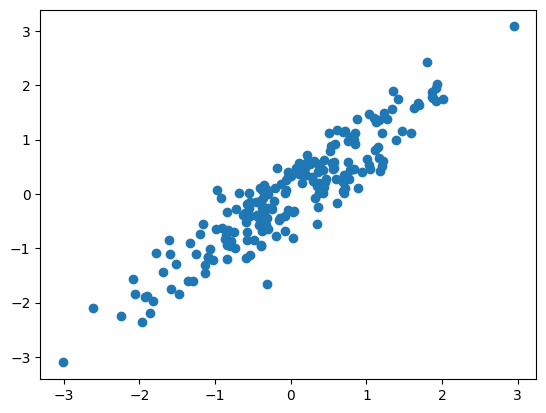

In [87]:
# plots
plt.figure() # initialized plot
plt.scatter(X_scaled[:,0],X_scaled[:,1]) # scatter plot
plt.show() # show the plot